<div style="background: linear-gradient(135deg, #0f2027, #203a43, #2c5364); padding: 38px 30px; border-radius: 14px; border-bottom: 4px solid #43e97b; font-family: Georgia, serif; color: #f0f4f8;">

<div style="font-size: 11px; letter-spacing: 5px; color: #43e97b; text-transform: uppercase; margin-bottom: 10px;">📖 University of Manchester ML Course</div>

<h1 style="font-size: 2.5em; font-weight: bold; margin: 0 0 12px 0; color: #ffffff; line-height: 1.2;">
Gaussian Mixture Models<br>
<span style="color: #43e97b; font-size: 0.7em; font-weight: normal; font-style: italic;">A Complete Beginner-to-Intermediate Guide</span>
</h1>

<p style="font-size: 1.05em; color: #b2c4d0; margin: 16px 0 0 0; line-height: 1.7;">
From intuition to implementation · Theory → Code → Real datasets<br>
<span style="font-size: 0.85em; color: #7f9aaa;">Suitable for undergraduates and postgraduates with basic Python and statistics knowledge</span>
</p>

<hr style="border: none; border-top: 1px solid #43e97b44; margin: 20px 0;"/>

<div style="display: flex; gap: 24px; flex-wrap: wrap; font-size: 0.85em; color: #b2c4d0;">
<span>🎓 <b style="color:#43e97b;">Level:</b> Undergraduate / Postgraduate</span>
<span>⏱️ <b style="color:#43e97b;">Duration:</b> ~90 minutes</span>
<span>🐍 <b style="color:#43e97b;">Prerequisites:</b> Basic Python, probability, linear algebra</span>
</div>
</div>


---
## 📋 Table of Contents

1. [Big Picture — What Problem Does GMM Solve?](#section1)
2. [Intuition First — No Math Yet!](#section2)
3. [The Mathematics (Made Accessible)](#section3)
4. [The EM Algorithm — Step by Step](#section4)
5. [Hands-On: Iris Dataset](#section5)
6. [Hands-On: Image Compression with GMM](#section6)
7. [Hands-On: GMM as a Density Estimator](#section7)
8. [Choosing K — Model Selection](#section8)
9. [Covariance Types Explained](#section9)
10. [Pros, Cons & When to Use GMM](#section10)
11. [GMM vs K-Means vs DBSCAN — Comparison](#section11)
12. [Exercises & Further Reading](#section12)

---


<a id='section1'></a>
## 1. 🌍 Big Picture — What Problem Does GMM Solve?

Imagine you have a dataset but **no labels**. You want to discover hidden structure — groups of similar data points — without anyone telling you what the groups are. This is **unsupervised learning**.

### Why Not Just Use K-Means?

K-means is fast and simple, but it has serious limitations:
- It assigns every point to exactly **one cluster** (hard assignment)
- It assumes clusters are **spherical** (same shape in all directions)
- It cannot express **uncertainty** — "this point might be in cluster A or B"

### Enter: Gaussian Mixture Models

GMM is a **probabilistic generative model** that:
- Assumes the data was *generated* by a mixture of several Gaussian distributions
- Gives each data point a **probability** of belonging to each cluster (soft assignment)
- Can model clusters of **any ellipsoidal shape** (via the covariance matrix)
- Has a solid mathematical foundation in **maximum likelihood estimation**

> **In one sentence:** GMM fits a weighted sum of Gaussian "bells" to your data, one bell per cluster.


---
<a id='section2'></a>
## 2. Setup — Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
from matplotlib.colors import ListedColormap
from scipy.stats import multivariate_normal, norm
from scipy import stats

from sklearn.mixture import GaussianMixture
from sklearn.datasets import load_iris, make_moons, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# ── Friendly, light-theme plot style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#fafbfc',
    'axes.facecolor':   '#f0f4f8',
    'axes.edgecolor':   '#bcc8d4',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'text.color':       '#1a2332',
    'axes.labelcolor':  '#1a2332',
    'xtick.color':      '#4a5568',
    'ytick.color':      '#4a5568',
    'grid.color':       '#dde4ed',
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'figure.dpi':       100,
    'axes.prop_cycle':  plt.cycler(color=['#e53e3e','#38a169','#3182ce','#d69e2e','#805ad5']),
})

# Colour palette
C = ['#e53e3e', '#38a169', '#3182ce', '#d69e2e', '#805ad5']
print("✅ Libraries loaded! Let's explore GMMs step by step.")


✅ Libraries loaded! Let's explore GMMs step by step.


---
## 2. 🎨 Intuition First — Building a GMM by Hand (1-D)

Before touching scikit-learn, let's *build* a 1-D GMM by hand to understand what it really is.

**Scenario:** Suppose student exam scores come from two populations:
- 📘 Students who studied hard → scores ≈ Normal(75, 8)
- 📕 Students who didn't study → scores ≈ Normal(45, 12)

The overall score distribution is a **mixture** of these two Gaussians.


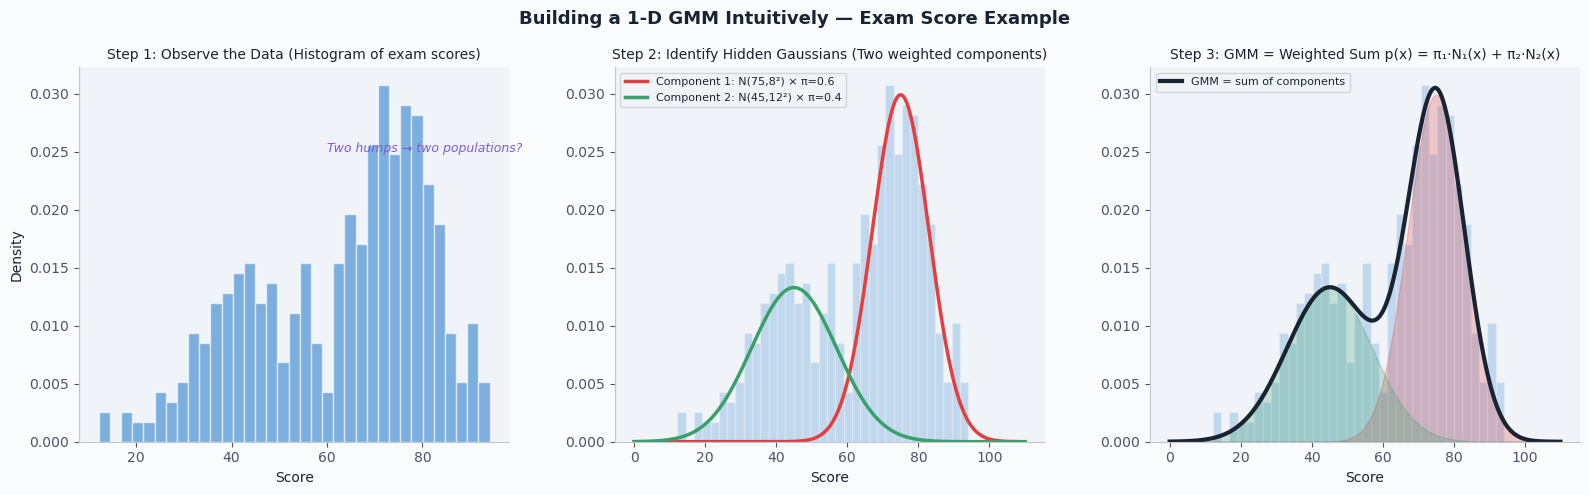

💡 Key insight: the GMM density (black line) closely follows the data histogram.
   GMM's job is to FIND these components from data alone, without knowing them in advance.


In [5]:
np.random.seed(0)

# True parameters (what generated the data)
pi_true   = [0.6, 0.4]            # 60% studied, 40% didn't
mu_true   = [75,  45]             # mean scores
sig_true  = [8,   12]             # std devs

# Generate sample data
n_total = 500
n1 = int(n_total * pi_true[0])
n2 = n_total - n1
scores = np.concatenate([
    np.random.normal(mu_true[0], sig_true[0], n1),
    np.random.normal(mu_true[1], sig_true[1], n2)
])
np.random.shuffle(scores)

x_plot = np.linspace(0, 110, 500)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Building a 1-D GMM Intuitively — Exam Score Example',
             fontsize=13, fontweight='bold')

# Panel 1: Raw histogram
axes[0].hist(scores, bins=35, color='#3182ce', alpha=0.6, edgecolor='white', density=True)
axes[0].set_title('Step 1: Observe the Data (Histogram of exam scores)', fontsize=10)
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Density')
axes[0].annotate('Two humps → two populations?', xy=(60, 0.025), fontsize=9,
                 color='#805ad5', style='italic')

# Panel 2: Individual Gaussians
pdf1 = norm.pdf(x_plot, mu_true[0], sig_true[0]) * pi_true[0]
pdf2 = norm.pdf(x_plot, mu_true[1], sig_true[1]) * pi_true[1]
axes[1].hist(scores, bins=35, color='#3182ce', alpha=0.25, edgecolor='white', density=True)
axes[1].plot(x_plot, pdf1, color=C[0], linewidth=2.5, label=f'Component 1: N({mu_true[0]},{sig_true[0]}²) × π={pi_true[0]}')
axes[1].plot(x_plot, pdf2, color=C[1], linewidth=2.5, label=f'Component 2: N({mu_true[1]},{sig_true[1]}²) × π={pi_true[1]}')
axes[1].set_title('Step 2: Identify Hidden Gaussians (Two weighted components)', fontsize=10)
axes[1].set_xlabel('Score')
axes[1].legend(fontsize=8)

# Panel 3: Combined mixture density
pdf_mix = pdf1 + pdf2
axes[2].hist(scores, bins=35, color='#3182ce', alpha=0.25, edgecolor='white', density=True)
axes[2].fill_between(x_plot, pdf1, alpha=0.25, color=C[0])
axes[2].fill_between(x_plot, pdf2, alpha=0.25, color=C[1])
axes[2].plot(x_plot, pdf_mix, color='#1a2332', linewidth=3, label='GMM = sum of components')
axes[2].set_title('Step 3: GMM = Weighted Sum p(x) = π₁·N₁(x) + π₂·N₂(x)', fontsize=10)
axes[2].set_xlabel('Score')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("💡 Key insight: the GMM density (black line) closely follows the data histogram.")
print("   GMM's job is to FIND these components from data alone, without knowing them in advance.")


---
<a id='section3'></a>
## 3. 📐 The Mathematics (Made Accessible)

### 3.1 Univariate Gaussian

A single Gaussian (normal) distribution for a scalar $x$:

$$\mathcal{N}(x \mid \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

- $\mu$ = mean (centre of the bell)
- $\sigma^2$ = variance (width of the bell)

### 3.2 Multivariate Gaussian (for real data with many features)

For a $d$-dimensional vector $\mathbf{x}$:

$$\mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{d/2}|\boldsymbol{\Sigma}|^{1/2}} \exp\!\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})\right)$$

- $\boldsymbol{\mu} \in \mathbb{R}^d$ = mean vector (one mean per feature)
- $\boldsymbol{\Sigma} \in \mathbb{R}^{d \times d}$ = covariance matrix (captures spread AND correlations)

### 3.3 The GMM

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \; \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

**Parameters to learn:** $\{\pi_k, \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k\}_{k=1}^{K}$

**Constraints:** $\pi_k \geq 0$ and $\sum_k \pi_k = 1$

### 3.4 The Responsibility (Posterior)

After observing $\mathbf{x}$, what is the probability that component $k$ generated it?

$$r_{nk} = p(z_n = k \mid \mathbf{x}_n) = \frac{\pi_k \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{j=1}^{K} \pi_j \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}$$

This is **Bayes' theorem** in action: combining the prior $\pi_k$ with the likelihood of $\mathbf{x}_n$ under component $k$.


---
<a id='section4'></a>
## 4. ⚙️ The EM Algorithm — Step by Step

EM is an iterative optimisation algorithm that alternates between two steps:

```
INITIALISE: K cluster centres (random or k-means)
│
├─► E-step (Expectation):
│     For each data point xₙ:
│       Compute rₙₖ = P(cluster k | xₙ)  ← soft assignment using Bayes
│
└─► M-step (Maximisation):
      Update parameters using responsibilities as weights:
        πₖ  ← mean of rₙₖ across all n
        μₖ  ← weighted mean of xₙ  (weight = rₙₖ)
        Σₖ  ← weighted covariance of xₙ  (weight = rₙₖ)
│
Repeat until log-likelihood stops improving (convergence)
```


In [6]:
# ── EM Algorithm implemented from scratch (1-D, 2 components) ─────────────────
class GMM_Scratch_1D:
    def __init__(self, K=2, max_iter=50, tol=1e-6, seed=0):
        self.K = K; self.max_iter = max_iter; self.tol = tol; self.seed = seed
        
    def fit(self, X):
        np.random.seed(self.seed)
        n = len(X)
        K = self.K
        
        # Initialise parameters randomly
        self.pi  = np.ones(K) / K
        idx = np.random.choice(n, K, replace=False)
        self.mu  = X[idx]
        self.sig = np.full(K, X.std())
        
        self.history = []
        prev_ll = -np.inf
        
        for iteration in range(self.max_iter):
            # ── E-step: compute responsibilities ──────────────────────────────
            R = np.zeros((n, K))
            for k in range(K):
                R[:, k] = self.pi[k] * norm.pdf(X, self.mu[k], self.sig[k])
            R_sum = R.sum(axis=1, keepdims=True)
            R = R / (R_sum + 1e-300)
            
            # ── M-step: update parameters ─────────────────────────────────────
            Nk = R.sum(axis=0)
            self.pi  = Nk / n
            self.mu  = (R * X[:, None]).sum(axis=0) / Nk
            self.sig = np.sqrt(((R * (X[:, None] - self.mu)**2).sum(axis=0)) / Nk)
            
            # ── Log-likelihood ─────────────────────────────────────────────────
            ll = np.log(R_sum + 1e-300).sum()
            self.history.append({'iter': iteration, 'll': ll,
                                 'mu': self.mu.copy(), 'pi': self.pi.copy()})
            if abs(ll - prev_ll) < self.tol:
                print(f"  ✅ Converged at iteration {iteration}")
                break
            prev_ll = ll
        return self
    
    def pdf(self, x_plot):
        return sum(self.pi[k] * norm.pdf(x_plot, self.mu[k], self.sig[k])
                   for k in range(self.K))

# Fit to exam score data
gmm_scratch = GMM_Scratch_1D(K=2, max_iter=100, seed=1).fit(scores)
print(f"\nLearned parameters:")
for k in range(2):
    print(f"  Component {k+1}: π={gmm_scratch.pi[k]:.3f}, μ={gmm_scratch.mu[k]:.1f}, σ={gmm_scratch.sig[k]:.1f}")
print(f"\nTrue parameters:")
for k in range(2):
    print(f"  Component {k+1}: π={pi_true[k]:.3f}, μ={mu_true[k]:.1f}, σ={sig_true[k]:.1f}")


  ✅ Converged at iteration 63

Learned parameters:
  Component 1: π=0.602, μ=75.1, σ=8.1
  Component 2: π=0.398, μ=43.7, σ=11.9

True parameters:
  Component 1: π=0.600, μ=75.0, σ=8.0
  Component 2: π=0.400, μ=45.0, σ=12.0


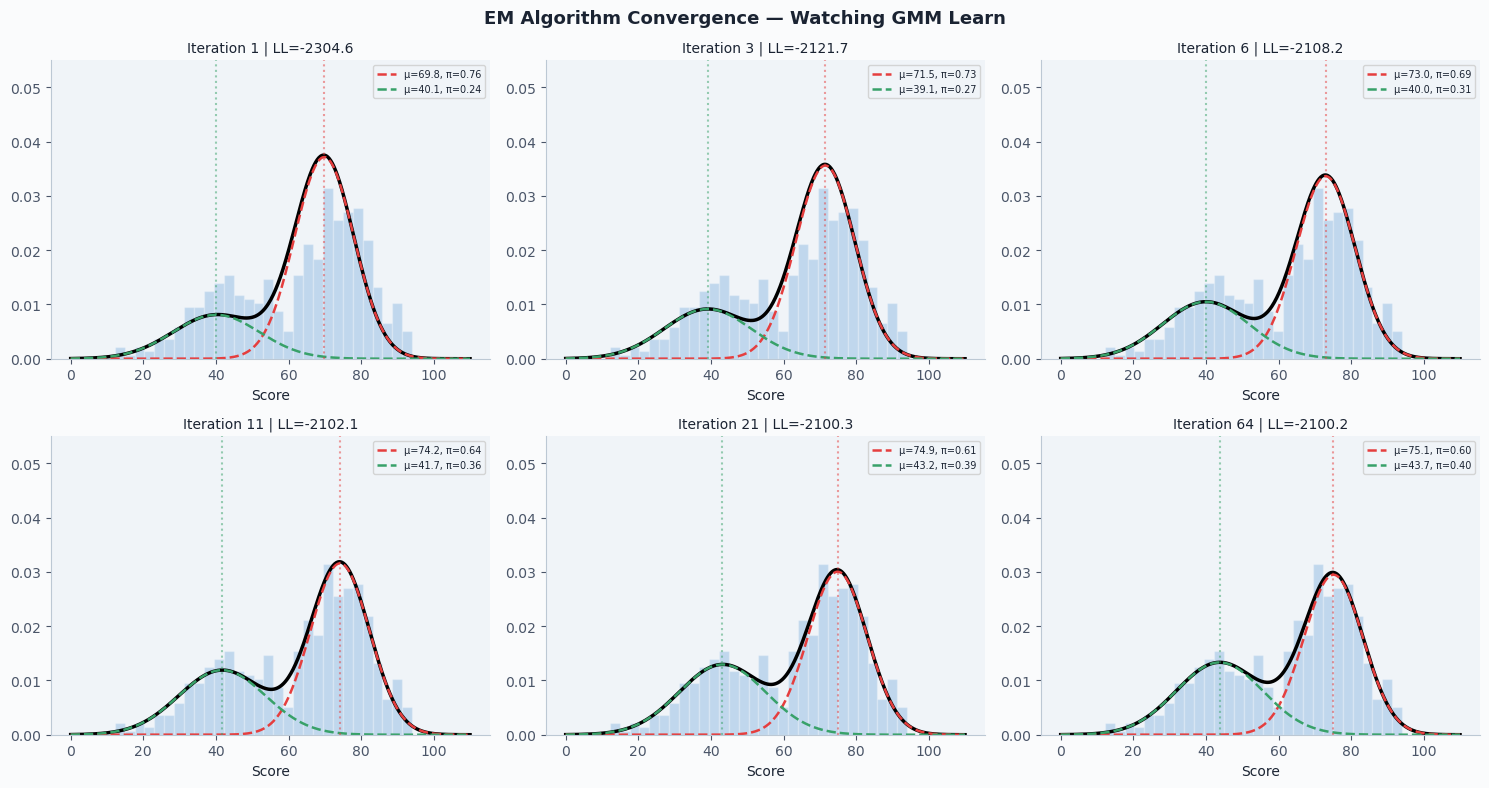

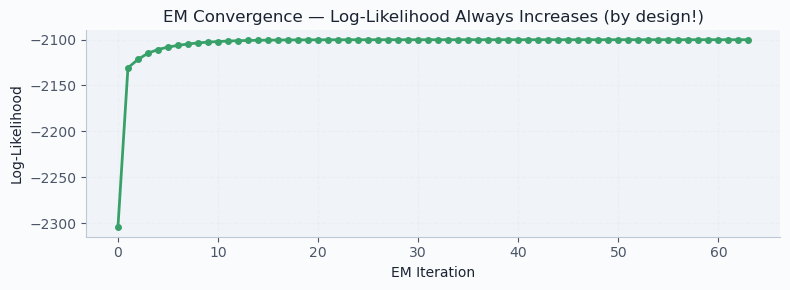

📌 Note: EM GUARANTEES log-likelihood never decreases — it's a monotone algorithm.


In [7]:
# ── Visualise EM convergence ───────────────────────────────────────────────────
iters_to_show = [0, 2, 5, 10, 20, len(gmm_scratch.history)-1]
iters_to_show = [i for i in iters_to_show if i < len(gmm_scratch.history)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('EM Algorithm Convergence — Watching GMM Learn', fontsize=13, fontweight='bold')

for ax, it in zip(axes.flatten(), iters_to_show):
    h = gmm_scratch.history[it]
    # Current pdf
    pdf_total = sum(h['pi'][k] * norm.pdf(x_plot, h['mu'][k], gmm_scratch.sig[k])
                    for k in range(2))
    ax.hist(scores, bins=30, density=True, color='#3182ce', alpha=0.25, edgecolor='white')
    ax.plot(x_plot, pdf_total, 'k-', linewidth=2.5)
    for k in range(2):
        comp_pdf = h['pi'][k] * norm.pdf(x_plot, h['mu'][k], gmm_scratch.sig[k])
        ax.plot(x_plot, comp_pdf, '--', color=C[k], linewidth=1.8,
                label=f'μ={h["mu"][k]:.1f}, π={h["pi"][k]:.2f}')
    ax.axvline(h['mu'][0], color=C[0], alpha=0.5, linestyle=':')
    ax.axvline(h['mu'][1], color=C[1], alpha=0.5, linestyle=':')
    ax.set_title(f'Iteration {it+1} | LL={h["ll"]:.1f}', fontsize=10)
    ax.legend(fontsize=7)
    ax.set_xlabel('Score'); ax.set_ylim(0, 0.055)

plt.tight_layout()
plt.show()

# ── Log-likelihood curve ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
ll_vals = [h['ll'] for h in gmm_scratch.history]
ax.plot(ll_vals, 'o-', color='#38a169', linewidth=2, markersize=4)
ax.set_xlabel('EM Iteration')
ax.set_ylabel('Log-Likelihood')
ax.set_title('EM Convergence — Log-Likelihood Always Increases (by design!)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("📌 Note: EM GUARANTEES log-likelihood never decreases — it's a monotone algorithm.")


---
<a id='section5'></a>
## 5. 🌸 Hands-On: GMM on the Iris Dataset

The classic Iris dataset has 3 species of flowers with 4 measurements each — a perfect test for a K=3 GMM.


In [8]:
# ── Load and scale Iris data ───────────────────────────────────────────────────
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

scaler_iris = StandardScaler()
X_iris_s = scaler_iris.fit_transform(X_iris)

pca_iris = PCA(n_components=2, random_state=0)
X_iris_2d = pca_iris.fit_transform(X_iris_s)

print(f"Dataset shape: {X_iris.shape}  ({X_iris.shape[0]} samples × {X_iris.shape[1]} features)")
print(f"Features: {feature_names}")
print(f"Classes: {class_names}  (n per class: {np.bincount(y_iris)})")


Dataset shape: (150, 4)  (150 samples × 4 features)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']  (n per class: [50 50 50])


In [9]:
# ── Fit GMM ────────────────────────────────────────────────────────────────────
gmm_iris = GaussianMixture(n_components=3, covariance_type='full',
                            n_init=20, random_state=42)
gmm_iris.fit(X_iris_s)

labels_gmm = gmm_iris.predict(X_iris_s)
proba_gmm   = gmm_iris.predict_proba(X_iris_s)

# ARI measures how well our labels match true species (ignores label permutation)
ari = adjusted_rand_score(y_iris, labels_gmm)
sil = silhouette_score(X_iris_s, labels_gmm)

print(f"Adjusted Rand Index (vs true species): {ari:.3f}  (1.0 = perfect)")
print(f"Silhouette Score                      : {sil:.3f}  (1.0 = perfect separation)")
print(f"\nMixing weights: {gmm_iris.weights_.round(3)}")


Adjusted Rand Index (vs true species): 0.904  (1.0 = perfect)
Silhouette Score                      : 0.374  (1.0 = perfect separation)

Mixing weights: [0.301 0.333 0.366]


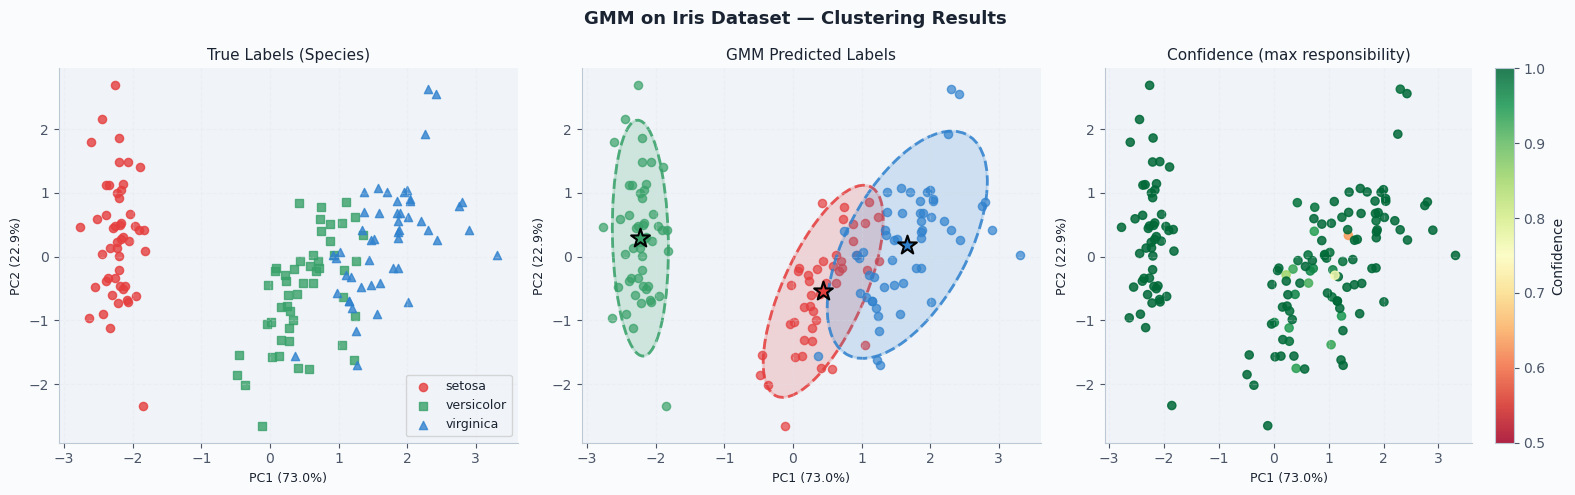

🌸 GMM correctly separates 3 Iris species with ARI = 0.904
   Ellipses = 2-sigma confidence regions per component
   Stars    = component means (cluster centres)
   Low-confidence points = near decision boundaries (correctly uncertain!)


In [10]:
def draw_ellipse_2d(ax, mean, cov, color, n_std=2.0, alpha=0.18):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h = 2 * n_std * np.sqrt(vals)
    for a, ls in [(alpha, 'solid'), (0, 'dashed')]:
        e = Ellipse(xy=mean, width=w, height=h, angle=angle,
                    edgecolor=color, facecolor=color if a else 'none',
                    alpha=a if a else 0.85, linewidth=2, linestyle=ls)
        ax.add_patch(e)

means_2d = pca_iris.transform(gmm_iris.means_)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('GMM on Iris Dataset — Clustering Results', fontsize=13, fontweight='bold')

titles = ['True Labels (Species)', 'GMM Predicted Labels', 'Confidence (max responsibility)']
markers = ['o', 's', '^']

# True labels
for k in range(3):
    mask = y_iris == k
    axes[0].scatter(X_iris_2d[mask, 0], X_iris_2d[mask, 1],
                    c=C[k], s=35, alpha=0.8, marker=markers[k], label=class_names[k])
axes[0].legend(fontsize=9)

# GMM predictions + ellipses
for k in range(3):
    mask = labels_gmm == k
    axes[1].scatter(X_iris_2d[mask, 0], X_iris_2d[mask, 1],
                    c=C[k], s=35, alpha=0.7, marker='o')
    cov_2d = pca_iris.components_ @ gmm_iris.covariances_[k] @ pca_iris.components_.T
    draw_ellipse_2d(axes[1], means_2d[k], cov_2d, C[k])
    axes[1].scatter(*means_2d[k], c=C[k], s=200, marker='*', edgecolors='black',
                    linewidths=1.5, zorder=10)

# Confidence
conf = proba_gmm.max(axis=1)
sc = axes[2].scatter(X_iris_2d[:, 0], X_iris_2d[:, 1], c=conf,
                      cmap='RdYlGn', s=35, alpha=0.85, vmin=0.5, vmax=1.0)
plt.colorbar(sc, ax=axes[2], label='Confidence')

for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(f'PC1 ({pca_iris.explained_variance_ratio_[0]:.1%})', fontsize=9)
    ax.set_ylabel(f'PC2 ({pca_iris.explained_variance_ratio_[1]:.1%})', fontsize=9)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print(f"🌸 GMM correctly separates 3 Iris species with ARI = {ari:.3f}")
print("   Ellipses = 2-sigma confidence regions per component")
print("   Stars    = component means (cluster centres)")
print("   Low-confidence points = near decision boundaries (correctly uncertain!)")


---
<a id='section7'></a>
## 7. 📈 GMM as a Density Estimator — Anomaly Detection

One of GMM's superpowers beyond clustering: it estimates the **probability density** of the data. This allows us to score new points:

- **High log-likelihood** → normal data point
- **Low log-likelihood** → outlier / anomaly

Let's demonstrate this with a synthetic dataset with injected anomalies.


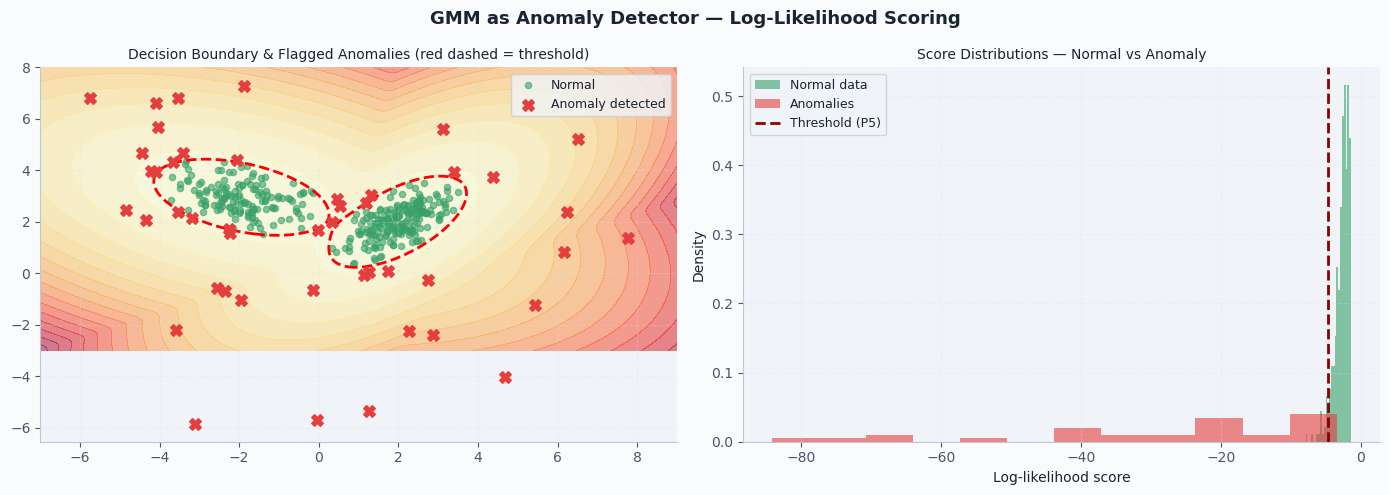

Anomaly detection: 28/30 true anomalies found, 18 false positives


In [12]:
np.random.seed(42)

# Normal data: two clusters
X_normal = np.vstack([
    np.random.multivariate_normal([2, 2], [[0.5, 0.3],[0.3, 0.5]], 200),
    np.random.multivariate_normal([-2, 3], [[0.8, -0.2],[-0.2, 0.4]], 150),
])
# Anomalies: scattered far from clusters
X_anomaly = np.random.uniform(-6, 8, (30, 2))
X_all = np.vstack([X_normal, X_anomaly])

gmm_ad = GaussianMixture(n_components=2, covariance_type='full',
                          n_init=10, random_state=0)
gmm_ad.fit(X_normal)   # ← FIT ONLY ON NORMAL DATA

ll_all = gmm_ad.score_samples(X_all)
threshold_ad = np.percentile(gmm_ad.score_samples(X_normal), 5)  # 5th percentile
is_anom = ll_all < threshold_ad

# ── Visualise ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GMM as Anomaly Detector — Log-Likelihood Scoring', fontsize=13, fontweight='bold')

# Decision boundary
xx, yy = np.meshgrid(np.linspace(-7, 9, 200), np.linspace(-3, 8, 200))
Z = gmm_ad.score_samples(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[0].contourf(xx, yy, Z, levels=15, cmap='YlOrRd_r', alpha=0.5)
axes[0].contour(xx, yy, Z, levels=[threshold_ad], colors='red', linewidths=2, linestyles='--')
axes[0].scatter(X_normal[:, 0], X_normal[:, 1], c='#38a169', s=20, alpha=0.6, label='Normal')
axes[0].scatter(X_anomaly[~is_anom[len(X_normal):], 0],
                X_anomaly[~is_anom[len(X_normal):], 1],
                c='#38a169', s=20, alpha=0.6)
axes[0].scatter(X_all[is_anom, 0], X_all[is_anom, 1],
                c='#e53e3e', s=70, marker='X', zorder=5, label='Anomaly detected')
axes[0].set_title('Decision Boundary & Flagged Anomalies (red dashed = threshold)', fontsize=10)
axes[0].legend(fontsize=9)

# Log-likelihood distribution
axes[1].hist(gmm_ad.score_samples(X_normal), bins=25, alpha=0.6, color='#38a169',
             density=True, label='Normal data')
axes[1].hist(gmm_ad.score_samples(X_anomaly), bins=12, alpha=0.6, color='#e53e3e',
             density=True, label='Anomalies')
axes[1].axvline(threshold_ad, color='darkred', linestyle='--', linewidth=2, label='Threshold (P5)')
axes[1].set_xlabel('Log-likelihood score')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distributions — Normal vs Anomaly', fontsize=10)
axes[1].legend(fontsize=9)

for ax in axes:
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

n_detected = is_anom[len(X_normal):].sum()
n_false_pos = is_anom[:len(X_normal)].sum()
print(f"Anomaly detection: {n_detected}/30 true anomalies found, {n_false_pos} false positives")


---
<a id='section8'></a>
## 8. 🔢 Choosing K — Model Selection

The number of components K is a hyperparameter you must choose. The two most common criteria:

| Criterion | Formula | Interpretation |
|-----------|---------|----------------|
| **AIC** | $-2\ln\hat{L} + 2p$ | Lower is better. Prefers more complex models (can overfit) |
| **BIC** | $-2\ln\hat{L} + p\ln n$ | Lower is better. Stronger complexity penalty (usually better for large n) |

where $p$ = number of free parameters, $n$ = number of data points, $\hat{L}$ = max likelihood.

**Rule of thumb:** Start with BIC. The "elbow" in the BIC curve is the optimal K. Always cross-check with domain knowledge.


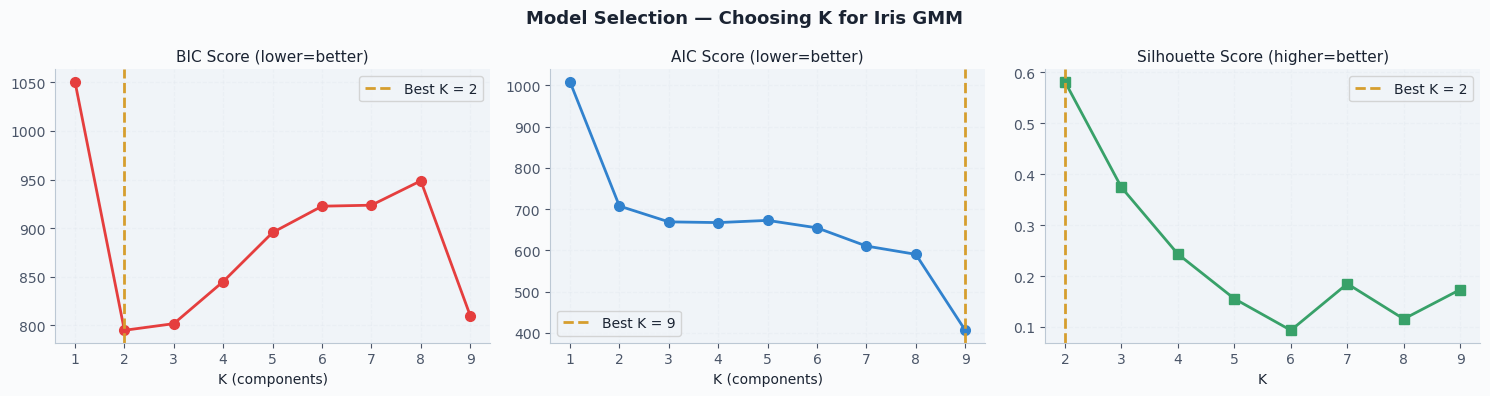

📊 BIC recommends K = 2
   AIC recommends K = 9
   True K = 3 (3 Iris species) ✅


In [13]:
K_vals = range(1, 10)
results = {'K': [], 'BIC': [], 'AIC': [], 'Sil': []}

for k in K_vals:
    g = GaussianMixture(n_components=k, covariance_type='full',
                         n_init=10, random_state=0, max_iter=200)
    g.fit(X_iris_s)
    results['K'].append(k)
    results['BIC'].append(g.bic(X_iris_s))
    results['AIC'].append(g.aic(X_iris_s))
    if k > 1:
        results['Sil'].append(silhouette_score(X_iris_s, g.predict(X_iris_s)))
    else:
        results['Sil'].append(np.nan)

df_sel = pd.DataFrame(results)
best_k_bic = df_sel.loc[df_sel['BIC'].idxmin(), 'K']
best_k_aic = df_sel.loc[df_sel['AIC'].idxmin(), 'K']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Model Selection — Choosing K for Iris GMM', fontsize=13, fontweight='bold')

for ax, col, title, best_k, color in [
    (axes[0], 'BIC', 'BIC Score (lower=better)', best_k_bic, '#e53e3e'),
    (axes[1], 'AIC', 'AIC Score (lower=better)', best_k_aic, '#3182ce'),
]:
    ax.plot(df_sel['K'], df_sel[col], 'o-', color=color, linewidth=2, markersize=7)
    ax.axvline(best_k, color='#d69e2e', linestyle='--', linewidth=2,
               label=f'Best K = {best_k}')
    ax.set_xlabel('K (components)'); ax.set_title(title, fontsize=11)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

axes[2].plot(df_sel['K'], df_sel['Sil'], 's-', color='#38a169', linewidth=2, markersize=7)
axes[2].axvline(df_sel.loc[df_sel['Sil'].idxmax(), 'K'], color='#d69e2e', linestyle='--',
                linewidth=2, label=f'Best K = {df_sel.loc[df_sel["Sil"].idxmax(), "K"]}')
axes[2].set_xlabel('K'); axes[2].set_title('Silhouette Score (higher=better)', fontsize=11)
axes[2].legend(fontsize=10); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 BIC recommends K = {best_k_bic}")
print(f"   AIC recommends K = {best_k_aic}")
print(f"   True K = 3 (3 Iris species) ✅")


---
<a id='section9'></a>
## 9. 🔷 Covariance Types Explained Visually

Scikit-learn supports 4 covariance structures. Understanding these is essential for choosing the right model complexity:


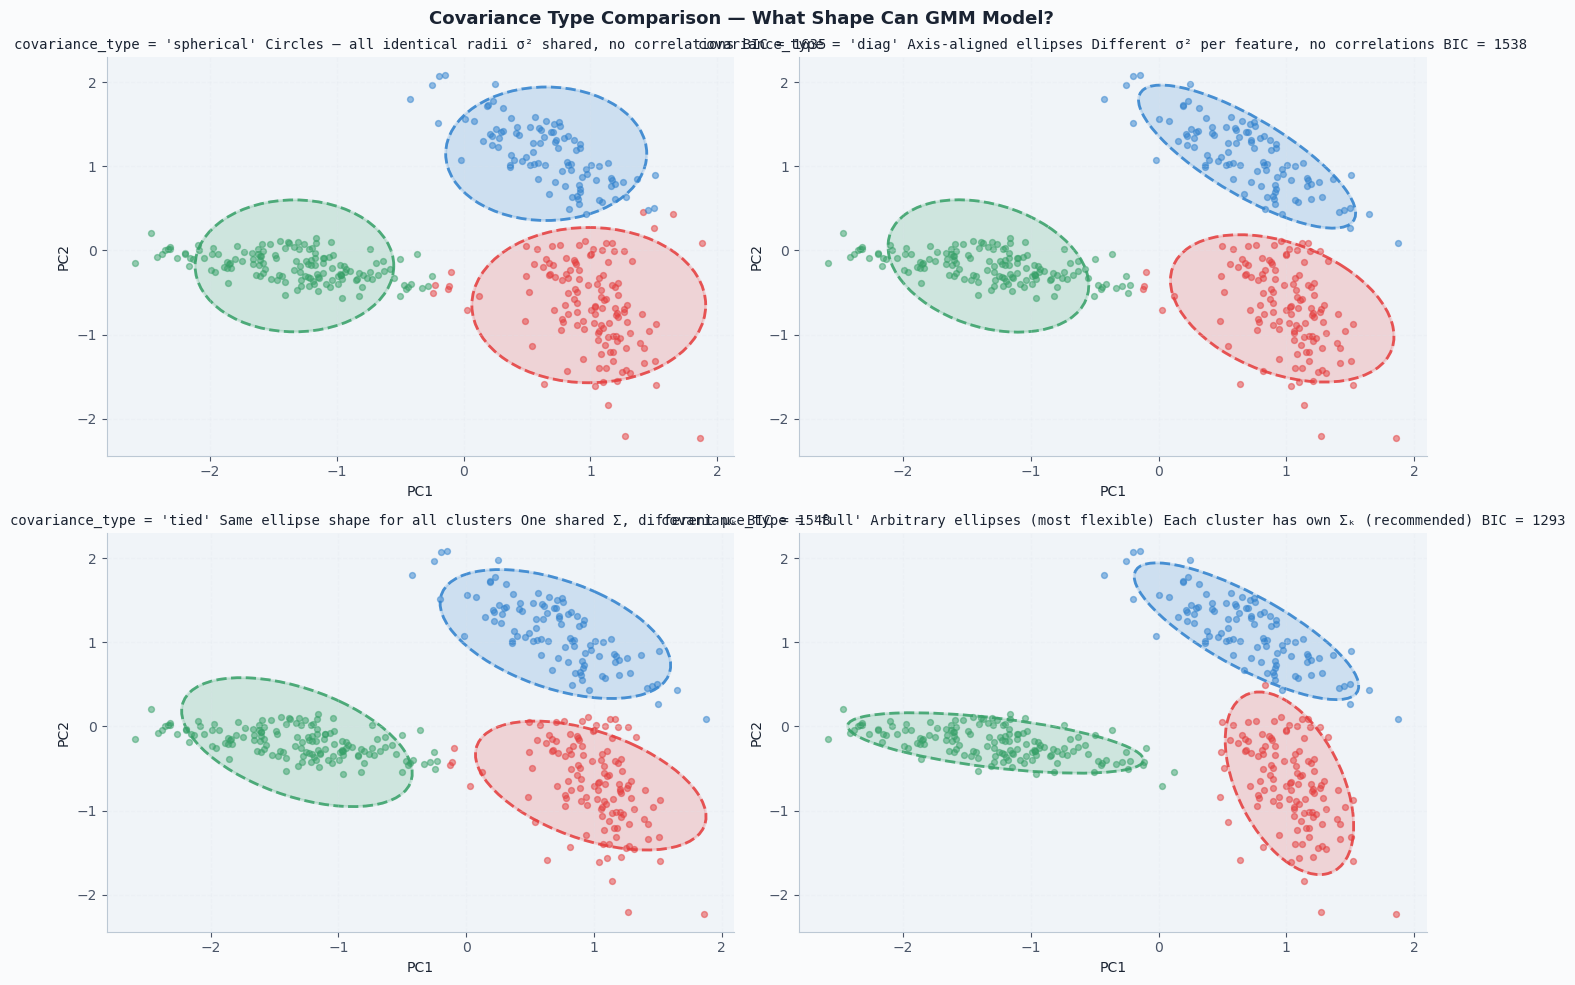

💡 'full' is the most flexible — but uses the most parameters (can overfit with small data)
   'diag' is a good balance for many real datasets
   'tied' useful when clusters differ only in location, not shape
   'spherical' = essentially k-means with soft assignments


In [18]:
# Generate data with different cluster shapes for illustration
np.random.seed(7)
X_shape = np.vstack([
    np.random.multivariate_normal([0, 0],  [[2.0, 1.5],[1.5, 1.5]], 150),
    np.random.multivariate_normal([5, 5],  [[1.5, -1.0],[-1.0, 1.5]], 120),
    np.random.multivariate_normal([9, 1],  [[0.5, 0],[0, 2.5]], 100),
])
X_shape_s = StandardScaler().fit_transform(X_shape)

cov_types = ['spherical', 'diag', 'tied', 'full']
descriptions = {
    'spherical': 'Circles — all identical radii σ² shared, no correlations',
    'diag':      'Axis-aligned ellipses Different σ² per feature, no correlations',
    'tied':      'Same ellipse shape for all clusters One shared Σ, different μₖ',
    'full':      'Arbitrary ellipses (most flexible) Each cluster has own Σₖ (recommended)',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Covariance Type Comparison — What Shape Can GMM Model?',
             fontsize=13, fontweight='bold')

for ax, ct in zip(axes.flatten(), cov_types):
    g = GaussianMixture(n_components=3, covariance_type=ct, n_init=10, random_state=0)
    g.fit(X_shape_s)
    lbl = g.predict(X_shape_s)
    
    pca_s = PCA(n_components=2, random_state=0).fit(X_shape_s)
    X_2d = pca_s.transform(X_shape_s)
    means_2d = pca_s.transform(g.means_)
    
    for k in range(3):
        mask = lbl == k
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=C[k], s=18, alpha=0.5)
        
        if ct == 'full':
            cov_k = pca_s.components_ @ g.covariances_[k] @ pca_s.components_.T
        elif ct == 'diag':
            cov_k = pca_s.components_ @ np.diag(g.covariances_[k]) @ pca_s.components_.T
        elif ct == 'spherical':
            cov_k = pca_s.components_ @ (np.eye(g.means_.shape[1])*g.covariances_[k]) @ pca_s.components_.T
        else:
            cov_k = pca_s.components_ @ g.covariances_ @ pca_s.components_.T
        try:
            draw_ellipse_2d(ax, means_2d[k], cov_k, C[k])
        except:
            pass
    
    bic_val = g.bic(X_shape_s)
    ax.set_title(f"covariance_type = '{ct}' {descriptions[ct]} BIC = {bic_val:.0f}", fontsize=10, fontfamily='monospace')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
print("💡 'full' is the most flexible — but uses the most parameters (can overfit with small data)")
print("   'diag' is a good balance for many real datasets")
print("   'tied' useful when clusters differ only in location, not shape")
print("   'spherical' = essentially k-means with soft assignments")


---
<a id='section10'></a>
## 10. ✅ Pros, ⚠️ Cons & 🎯 When to Use GMM

---

### ✅ Advantages of GMM

| Advantage | Explanation |
|-----------|-------------|
| **Probabilistic output** | Returns P(cluster k | x) — soft, uncertainty-aware assignments |
| **Flexible cluster shapes** | Full covariance models ellipsoidal (non-spherical) clusters |
| **Principled model selection** | BIC/AIC give theoretically grounded choice of K |
| **Density estimation** | Score new points; detect anomalies via log-likelihood |
| **Generative model** | You can sample new synthetic data from the fitted GMM |
| **Well-studied theory** | Convergence guarantees; connection to EM, Bayes, information theory |

---

### ⚠️ Limitations

| Limitation | When It Matters |
|------------|----------------|
| **Assumes Gaussian components** | Fails on ring, moon, crescent shapes — use DBSCAN/kernel methods |
| **K must be specified** | No automatic K discovery (unlike DBSCAN) |
| **EM can find local optima** | Use `n_init > 1` always; try different seeds |
| **Slow for large datasets** | n > 100,000 → consider mini-batch GMM or VB-GMM |
| **Degeneracy (σ→0)** | If a component collapses to one point — add `reg_covar` |
| **Poor with high d** | Curse of dimensionality — apply PCA before GMM for d > 20 |

---

### 🎯 Best Use Cases for GMM

```
✅ GMM EXCELS WHEN:
  • You expect ellipsoidal, overlapping clusters
  • You need probabilistic (soft) cluster assignments
  • You need to generate synthetic data (generative modelling)
  • You're doing anomaly / novelty detection
  • You need a density model (not just cluster labels)
  • Features are roughly Gaussian (or can be made so via transforms)

⚠️ CONSIDER ALTERNATIVES WHEN:
  • Clusters are non-convex (rings, crescents, spirals) → DBSCAN or SpectralClustering
  • K is completely unknown and noisy data is present → DBSCAN
  • Dataset is very large (>500k rows) → Mini-batch or BayesianGMM
  • You need strict hierarchical structure → AgglomerativeClustering

📚 REAL-WORLD APPLICATIONS:
  • Speaker recognition & diarisation (audio segments)
  • Image segmentation (pixel colour distributions)  
  • Bioinformatics (gene expression profiles)
  • Finance (regime detection in asset returns)
  • NLP (topic modelling proxy, document clustering)
  • Sensor fusion & anomaly detection (IoT, manufacturing)
```


---
<a id='section11'></a>
## 11. ⚔️ GMM vs K-Means vs DBSCAN — Side-by-Side Comparison


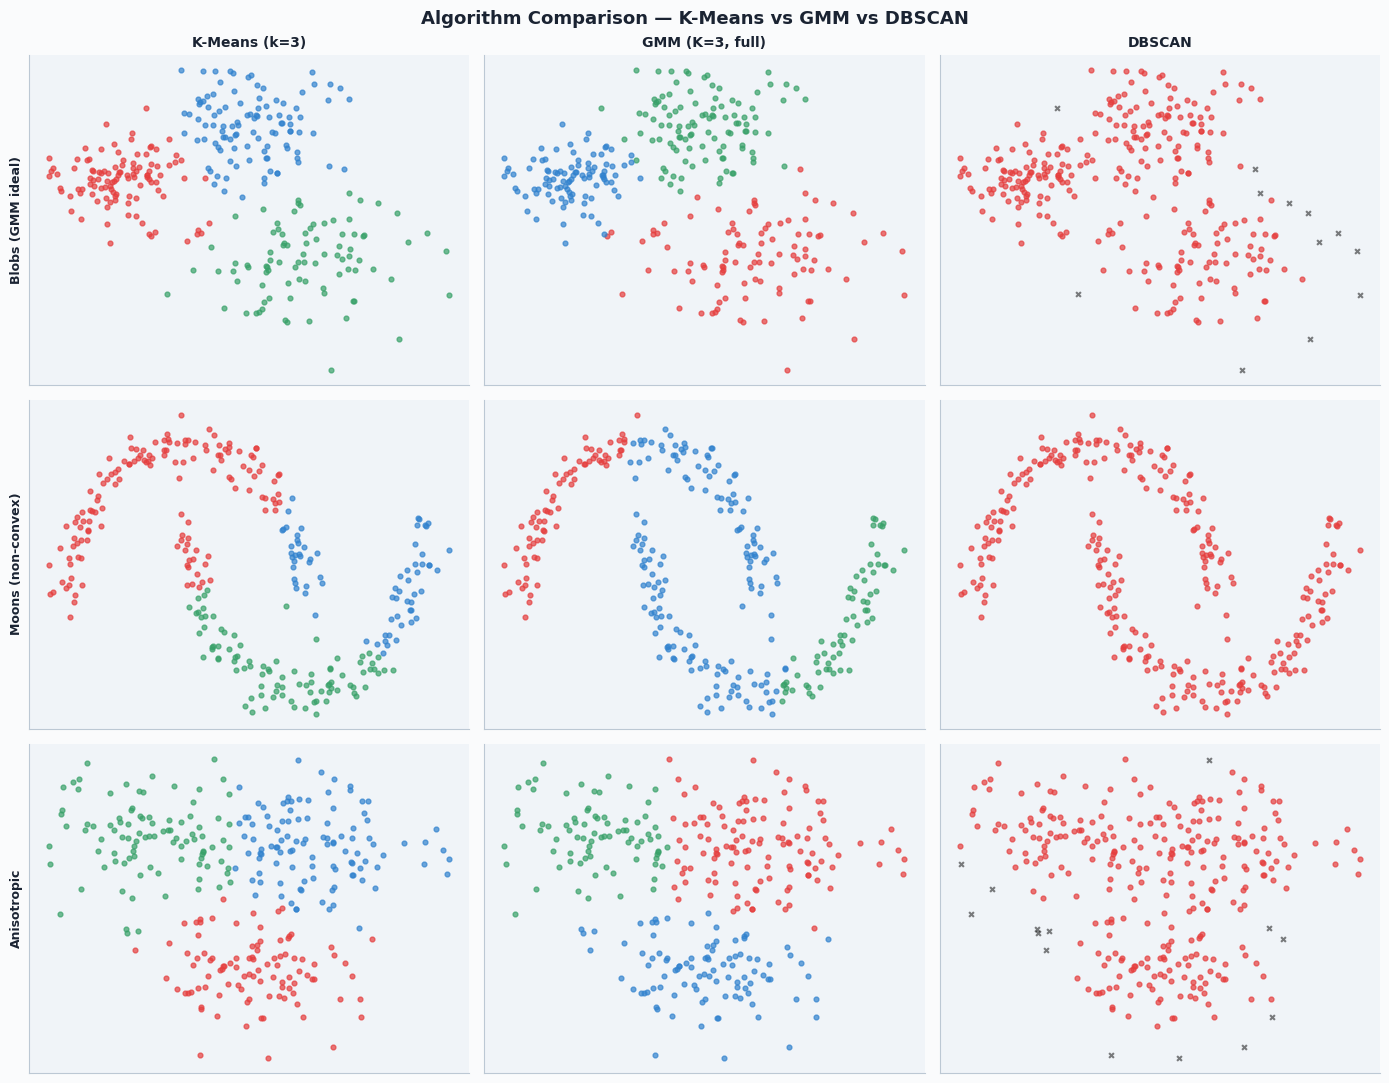

📊 Observations:
  Row 1 (Blobs):       All three work well. GMM gives probability scores too.
  Row 2 (Moons):       K-Means and GMM FAIL — non-convex shape. DBSCAN succeeds.
  Row 3 (Anisotropic): K-Means fails (assumes equal spheres). GMM handles it well.


In [19]:
from sklearn.cluster import DBSCAN

np.random.seed(0)

# Create three benchmark datasets
datasets = {
    'Blobs (GMM ideal)': make_blobs(n_samples=300, centers=3, cluster_std=[0.8, 1.2, 0.6],
                                     random_state=0)[0],
    'Moons (non-convex)': make_moons(n_samples=300, noise=0.08, random_state=0)[0],
    'Anisotropic': (lambda: (lambda X: X @ [[0.6, -0.6],[0.4, 0.8]])
                    (make_blobs(300, centers=3, random_state=0)[0]))(),
}

algorithms = {
    'K-Means (k=3)':  lambda X: KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(X),
    'GMM (K=3, full)': lambda X: GaussianMixture(3, covariance_type='full', n_init=10, random_state=0).fit_predict(X),
    'DBSCAN':          lambda X: DBSCAN(eps=0.4, min_samples=5).fit_predict(X),
}

fig, axes = plt.subplots(len(datasets), len(algorithms), figsize=(14, 11))
fig.suptitle('Algorithm Comparison — K-Means vs GMM vs DBSCAN', 
             fontsize=13, fontweight='bold')

for row, (dname, X) in enumerate(datasets.items()):
    Xs = StandardScaler().fit_transform(X)
    for col, (aname, algo) in enumerate(algorithms.items()):
        ax = axes[row][col]
        labels = algo(Xs)
        unique_labels = np.unique(labels[labels >= 0])
        cmap = [C[i % len(C)] for i in range(len(unique_labels))]
        
        for i, lbl in enumerate(unique_labels):
            mask = labels == lbl
            ax.scatter(Xs[mask, 0], Xs[mask, 1], c=cmap[i], s=12, alpha=0.7)
        
        noise_mask = labels == -1
        if noise_mask.any():
            ax.scatter(Xs[noise_mask, 0], Xs[noise_mask, 1],
                       c='black', s=12, alpha=0.5, marker='x')
        
        if row == 0:
            ax.set_title(aname, fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(dname, fontsize=9, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
        ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("📊 Observations:")
print("  Row 1 (Blobs):       All three work well. GMM gives probability scores too.")
print("  Row 2 (Moons):       K-Means and GMM FAIL — non-convex shape. DBSCAN succeeds.")
print("  Row 3 (Anisotropic): K-Means fails (assumes equal spheres). GMM handles it well.")


In [20]:
# ── Quick-reference comparison table ─────────────────────────────────────────
comparison = {
    'Property':          ['Assignment', 'Cluster shape', 'Density estimation',
                          'Handles noise', 'Needs K', 'Speed (large n)',
                          'Probabilistic', 'Interpretable'],
    'K-Means':           ['Hard', 'Spherical', '❌', '❌', '✅ required', '✅ Fast',
                          '❌', '✅'],
    'GMM':               ['Soft ✨', 'Ellipsoidal', '✅', 'Partial', '✅ required', '⚠️ Medium',
                          '✅', '✅'],
    'DBSCAN':            ['Hard', 'Arbitrary', '❌', '✅ automatic', '❌ (uses ε)', '✅ Fast',
                          '❌', '⚠️'],
}

df_comp = pd.DataFrame(comparison).set_index('Property')
print("=" * 65)
print("         CLUSTERING ALGORITHM QUICK REFERENCE")
print("=" * 65)
print(df_comp.to_string())
print("=" * 65)


         CLUSTERING ALGORITHM QUICK REFERENCE
                       K-Means          GMM       DBSCAN
Property                                                
Assignment                Hard       Soft ✨         Hard
Cluster shape        Spherical  Ellipsoidal    Arbitrary
Density estimation           ❌            ✅            ❌
Handles noise                ❌      Partial  ✅ automatic
Needs K             ✅ required   ✅ required   ❌ (uses ε)
Speed (large n)         ✅ Fast    ⚠️ Medium       ✅ Fast
Probabilistic                ❌            ✅            ❌
Interpretable                ✅            ✅           ⚠️


---
<a id='section12'></a>
## 12. 📝 Exercises & Challenges

### Beginner
1. **Change K:** Refit the Iris GMM with K=2 and K=5. What happens to BIC? What does K=2 group together?
2. **Change covariance type:** Replace `'full'` with `'diag'` and `'spherical'`. Compare BIC scores.
3. **1-D GMM:** Generate your own mixture of 3 Gaussians and verify that GMM recovers the parameters.

### Intermediate
4. **Anomaly detection tuning:** In Section 7, change the percentile threshold from P5 to P1 and P10. How does the false positive rate change?
5. **Wine dataset:** Apply GMM to `sklearn.datasets.load_wine()` (13 features, 3 classes). Can GMM separate the wine cultivars?
6. **Synthetic data generation:** Fit a GMM and use `gmm.sample(1000)` to generate new synthetic data. Plot alongside real data.

### Advanced
7. **Bayesian GMM:** Replace `GaussianMixture` with `BayesianGaussianMixture` (which determines K automatically via Dirichlet process). Compare results.
8. **Streaming / online GMM:** Implement a sliding-window GMM on a time series to detect regime changes.
9. **GMM + PCA pipeline:** Build a `sklearn.Pipeline` combining `StandardScaler → PCA(n_components=0.95) → GMM`. Cross-validate with `silhouette_score`.

---

### 📚 Recommended Reading

| Resource | What you'll learn |
|----------|------------------|
| **Bishop (2006)** *Pattern Recognition and Machine Learning*, Ch. 9 | Full EM derivation |
| **Murphy (2012)** *Machine Learning: A Probabilistic Perspective*, Ch. 11 | Mixture models from scratch |
| **sklearn docs** https://scikit-learn.org/stable/modules/mixture.html | Practical API reference |
| **Reynolds (2009)** *Gaussian Mixture Models* (MIT Encyclopedia) | Concise mathematical review |

---

> **🎓 Notebook Summary:**  
> You've gone from intuition → mathematics → scratch implementation → real datasets → anomaly detection → critical evaluation. GMM is one of the most elegant unsupervised learning methods, combining probabilistic rigour with practical flexibility. Master it and you'll have a powerful tool in your ML toolkit.
